<a href="https://colab.research.google.com/github/student-uzma/CSL701-CS10_Machine-Learning-Lab/blob/main/CS10_ML_Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name: Uzma choudhary Roll no:-CS10 Batch:-CS10

Name : Mahendra Choudhari
Roll No.:CS09

### Aim : To implement a **Logistic Regression** model to classify credit card transactions as **fraudulent or legitimate**.


## Objectives

1. To understand the mathematical foundations of **Logistic Regression** and the **Sigmoid Function**.
2. To understand and handle **class imbalance** in credit card fraud datasets.
3. To implement **Gradient Descent** for optimizing Logistic Regression parameters.
4. To evaluate the model using **Confusion Matrix, Precision, Recall, F1-Score, ROC Curve, and AUC**.
5. To understand the importance of **Recall and False Negative Rate** in fraud detection.


## Relevant Theory

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for **binary classification**. In this experiment, it is used to classify credit card transactions into two classes:

- **0 $\rightarrow$ Legitimate transaction**
- **1 $\rightarrow$ Fraudulent transaction**

The model first calculates a linear combination of input features:

$$
z = w^T X + b
$$

where:

- $w$ = weight vector
- $X$ = input feature vector
- $b$ = bias/intercept
- $z$ = linear predictor

---

### Sigmoid Function

The Sigmoid Function converts the value of $z$ into a probability between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability that a transaction is fraudulent is:

$$
P(y=1|X) = \sigma(w^T X + b)
$$

The predicted class can be obtained using a threshold:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y=1|X) \geq 0.5 \\
0, & \text{if } P(y=1|X) < 0.5
\end{cases}
$$

---
## Cost Function

Logistic Regression uses the **Binary Cross-Entropy Loss** or **Log Loss**.

The cost function is:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

- $m$ = number of training examples
- $y_i$ = actual class label
- $\hat{y}_i$ = predicted probability

The objective of training is to find values of $w$ and $b$ that minimize the cost function.

---

## Gradient Descent

Gradient Descent is used to optimize the parameters of the Logistic Regression model.

The weights are updated using:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

The bias is updated using:

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

For Logistic Regression, the gradient of the cost function with respect to the weights can be expressed as:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

The gradient with respect to the bias is:

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
$$

Therefore, the parameter updates become:

$$
w := w - \alpha
\left[
\frac{1}{m}X^T(\hat{y}-y)
\right]
$$

$$
b := b - \alpha
\left[
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
\right]
$$

---

## Class Imbalance

Credit card fraud datasets are generally highly imbalanced because legitimate transactions significantly outnumber fraudulent transactions.

For example, the dataset may contain a very large number of legitimate transactions and only a small number of fraudulent transactions.

A model that predicts most transactions as legitimate may achieve high accuracy but perform poorly at detecting fraud.

Therefore, techniques such as:

- Random Undersampling
- Oversampling
- Class Weighting

can be used to handle class imbalance.

---

## Evaluation Metrics

### Confusion Matrix

The confusion matrix consists of four components:

- **True Positive (TP):** Fraudulent transaction correctly identified as fraud.
- **True Negative (TN):** Legitimate transaction correctly identified as legitimate.
- **False Positive (FP):** Legitimate transaction incorrectly identified as fraud.
- **False Negative (FN):** Fraudulent transaction incorrectly identified as legitimate.

---

### Accuracy

Accuracy measures the proportion of correctly classified transactions:

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

However, accuracy alone is not sufficient for highly imbalanced fraud detection datasets.

---

### Precision

Precision indicates the proportion of transactions predicted as fraudulent that are actually fraudulent:

$$
Precision =
\frac{TP}
{TP+FP}
$$

A high Precision means that the model produces fewer false fraud alerts.

---

### Recall

Recall measures the proportion of actual fraudulent transactions correctly detected:

$$
Recall =
\frac{TP}
{TP+FN}
$$

Recall is particularly important in fraud detection because a **False Negative** represents a fraudulent transaction that was not detected.

---

### F1-Score

F1-Score is the harmonic mean of Precision and Recall:

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

---

## ROC Curve

The Receiver Operating Characteristic (ROC) curve represents the relationship between the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** at different classification thresholds.

The True Positive Rate is:

$$
TPR =
\frac{TP}
{TP+FN}
$$

The False Positive Rate is:

$$
FPR =
\frac{FP}
{FP+TN}
$$

The ROC curve helps determine how well the model separates fraudulent transactions from legitimate transactions.

---

## *Area Under the Curve (AUC)*

The **Area Under the ROC Curve (AUC)** summarizes the performance of the classifier across different classification thresholds.

An AUC value close to:

$$
AUC = 1
$$

indicates excellent discrimination, while:

$$
AUC = 0.5
$$

indicates performance approximately equivalent to random classification.

---

### Dataset Information

The Credit Card Fraud Dataset contains transaction-related features such as transaction amount, distance from home, purchase-price-related ratios, and transaction characteristics.

The target variable is fraud:


0 → Legitimate transaction

1 → Fraudulent transaction

---

## Task 1: Environment Setup and Dataset Acquisition

Use dataset for this experiment [Credit Card Fraud Dataset](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)

Import the required Python libraries such as **NumPy, Pandas, Matplotlib, and Scikit-learn**.

Load the **Credit Card Fraud Dataset** into a Pandas DataFrame.

Display the following information:

* First five records of the dataset.
* Shape of the dataset.
* Column names.
* Data types of all columns.
* Descriptive statistics of numerical features.

Identify the **feature variables** and the **target variable** `fraud`.

The target variable is defined as:

$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

fraud =

* 0 -> Legitimate transaction

* 1 -> Fraudulent transaction


The objective of this task is to understand the structure of the dataset and identify the input features and target variable required for building the Logistic Regression model.

Identify the feature variables and the target variable fraud.

In [ ]:
# Task 1: Environment Setup and Dataset Acquisition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# Load the dataset
df = pd.read_csv("card_transdata.csv")

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display shape
print("\nShape of dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types
print("\nData types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

# Separate features and target
X = df.drop("fraud", axis=1)
y = df["fraud"]

print("\nFeature variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print("fraud")

First 5 records:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0



Shape of dataset:
(1000000, 8)

Column names:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

Data types:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Descriptive statistics:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000



Feature variables:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Target variable:
fraud


## Task 2: Perform Exploratory Data Analysis

Perform **Exploratory Data Analysis (EDA)** to understand the structure, distribution, and characteristics of the Credit Card Fraud Dataset.

Calculate and display the following:

* Number of **legitimate transactions**.
* Number of **fraudulent transactions**.
* Percentage of legitimate transactions.
* Percentage of fraudulent transactions.
* Distribution of numerical features.

The percentage of each class can be calculated using:
$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

Plot the **class distribution** using a suitable visualization such as a bar chart.

Analyze the class distribution and explain the problem of **classification imbalance** in credit card fraud detection.

A dataset is considered highly imbalanced when the number of legitimate transactions is significantly greater than the number of fraudulent transactions. Therefore, accuracy alone may not be sufficient to evaluate the performance of the fraud detection model.


In [ ]:
# Task 2: Check Missing Values and Class Distribution

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check the distribution of the target variable
print("\nFraud Class Distribution:")
print(df["fraud"].value_counts())

# Check the percentage distribution
print("\nFraud Class Percentage:")
print(df["fraud"].value_counts(normalize=True) * 100)

Missing Values:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Fraud Class Distribution:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Fraud Class Percentage:
fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64


## Task 3: Data Preprocessing

Check the dataset for the following:

* Missing values.
* Duplicate records.
* Categorical variables.
* Numerical variables.

Identify the number of missing values in each column and handle them using suitable techniques such as **removal or imputation**.

Identify categorical variables and convert them into numerical form using appropriate **encoding techniques**.

For example, categorical variables can be converted into numerical values using **One-Hot Encoding**.

Also, identify the numerical features that will be used for building the Logistic Regression model.

The objective of this task is to prepare a clean and suitable dataset for further processing, feature scaling, model training, and evaluation.


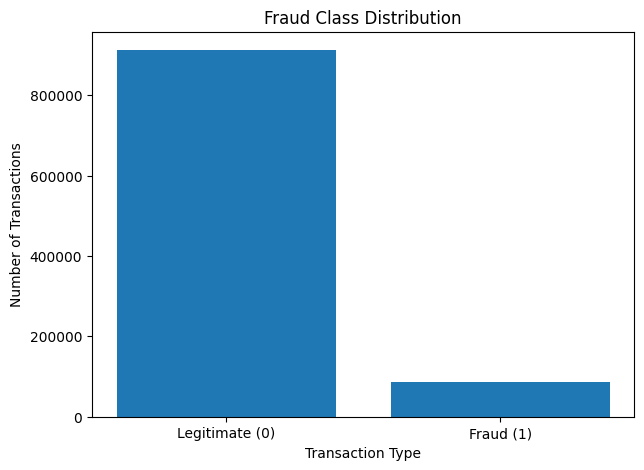

In [ ]:
# Task 3: Visualize Fraud Class Distribution

import matplotlib.pyplot as plt

# Count the fraud classes
fraud_counts = df["fraud"].value_counts()

# Create bar chart
plt.figure(figsize=(7, 5))
plt.bar(["Legitimate (0)", "Fraud (1)"], fraud_counts.values)

plt.title("Fraud Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

## Task 4: Feature Scaling and Class Imbalance Handling

Standardize the numerical features using **Standardization** so that they have approximately zero mean and unit variance.

The standardized value of a feature is calculated as:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

* (x) = original feature value
* (\mu) = mean of the feature
* (\sigma) = standard deviation of the feature
* (z) = standardized feature value

Handle the **class imbalance** in the dataset using a suitable technique such as:

* Random Undersampling
* Oversampling
* Class Weighting

Display the class distribution **before and after** applying the selected class-imbalance handling technique.

Compare the number of legitimate and fraudulent transactions before and after balancing.

The objective of this task is to ensure that the features are on a comparable scale and that the Logistic Regression model does not become biased toward the majority class.


In [ ]:
# Task 4: Separate Features and Target Variable

# Features (independent variables)
X = df.drop("fraud", axis=1)

# Target (dependent variable)
y = df["fraud"]

# Display the shapes
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display feature names
print("\nFeature variables:")
print(X.columns.tolist())

# Display target variable
print("\nTarget variable:")
print(y.name)

Features (X) shape: (1000000, 7)
Target (y) shape: (1000000,)

Feature variables:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Target variable:
fraud


## Task 5: Split the Dataset

Divide the preprocessed dataset into three subsets:

* **Training Set -- 60%**
* **Validation Set -- 20%**
* **Test Set -- 20%**

Use **stratified splitting** to maintain a representative proportion of fraudulent and legitimate transactions in each subset.

The dataset should first be divided into training and temporary sets. The temporary set should then be divided equally into validation and test sets.

The objective of this task is to use the training set for model training, the validation set for model evaluation and parameter selection, and the test set for final performance evaluation.


In [ ]:
# Task 5: Train-Test Split

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

# Display train-test percentage
print("\nTrain/Test Split:")
print("Training data:", len(X_train) / len(X) * 100, "%")
print("Testing data:", len(X_test) / len(X) * 100, "%")

Training features: (800000, 7)
Testing features: (200000, 7)
Training target: (800000,)
Testing target: (200000,)

Train/Test Split:
Training data: 80.0 %
Testing data: 20.0 %


## Task 6: Implement Sigmoid and Cost Functions

Implement the **Sigmoid Function** used in Logistic Regression.

The Sigmoid Function is defined as:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

The Sigmoid Function converts the output of the linear equation into a probability value between 0 and 1.

Implement the **Binary Cross-Entropy Cost Function**:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

* (m) = number of training samples
* (y_i) = actual class label
* (\hat{y}_i) = predicted probability
* (w) = weight vector
* (b) = bias

Test the Sigmoid Function using suitable sample values.

Calculate the initial cost of the Logistic Regression model using the initialized weights and bias.

The objective of this task is to understand how the Sigmoid Function produces probabilities and how the Binary Cross-Entropy Cost Function measures the error of the Logistic Regression model.


In [ ]:
# Task 6: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display the shapes
print("Scaled training features:", X_train_scaled.shape)
print("Scaled testing features:", X_test_scaled.shape)

# Display first 5 scaled records
print("\nFirst 5 scaled training records:")
print(X_train_scaled[:5])

Scaled training features: (800000, 7)
Scaled testing features: (200000, 7)

First 5 scaled training records:
[[-0.35354111  0.08304936 -0.57372634  0.36682676  1.36114699 -0.33463274
   0.73267685]
 [-0.17568325 -0.15658031  0.31517042  0.36682676  1.36114699 -0.33463274
   0.73267685]
 [ 0.07846709 -0.07031898 -0.53958994  0.36682676 -0.73467451 -0.33463274
   0.73267685]
 [-0.25018774 -0.18794044 -0.52698538  0.36682676 -0.73467451 -0.33463274
  -1.36485818]
 [ 0.83993842 -0.01098406 -0.19206255  0.36682676 -0.73467451 -0.33463274
  -1.36485818]]


## Task 7: Implement Logistic Regression Using Gradient Descent

Implement **Logistic Regression from scratch** using NumPy without directly using the Scikit-learn Logistic Regression implementation.

Initialize the model parameters, including the **weight vector** (w) and **bias** (b).

Calculate the predicted probability using the Sigmoid Function:

$$
\hat{y} = \sigma(Xw+b)
$$

where:

* (X) = input feature matrix
* (w) = weight vector
* $\hat{y} = \text{predicted probability}$


Calculate the gradients of the cost function with respect to the weights and bias:

<div align="left">

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

</div>

Update the model parameters using **Gradient Descent**:

$$
w := w-\alpha\frac{\partial J}{\partial w}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

where ($\alpha$) represents the **learning rate**.

Train the model for a suitable number of iterations and record the cost value during each iteration.

Plot **Cost vs. Iteration** to verify whether the optimization process is converging.

The objective of this task is to implement Logistic Regression manually and understand how Gradient Descent optimizes the model parameters by minimizing the Binary Cross-Entropy Cost Function.


In [ ]:
# Task 7: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Task 8: Generate Predictions and Evaluate the Confusion Matrix

Use the trained Logistic Regression model to calculate the **fraud probabilities** for the validation and test datasets.

The predicted probability is calculated using:

$$
\hat{y} = \sigma(Xw+b)
$$

Convert the predicted probabilities into class labels using a threshold of **0.5**:

$$
\hat{y}_{class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \
0, & \text{if } \hat{y} < 0.5
\end{cases}
$$

Construct the **Confusion Matrix** and identify the following:

* **True Positive (TP):** Fraudulent transactions correctly classified as fraudulent.
* **True Negative (TN):** Legitimate transactions correctly classified as legitimate.
* **False Positive (FP):** Legitimate transactions incorrectly classified as fraudulent.
* **False Negative (FN):** Fraudulent transactions incorrectly classified as legitimate.

The confusion matrix can be represented as:

$$
\text{Confusion Matrix} =
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

Explain the meaning of each result in the context of **credit card fraud detection**.

The objective of this task is to evaluate the classification results of the Logistic Regression model and understand the different types of prediction errors, with particular attention to **False Negatives**, which represent fraudulent transactions that are not detected.


In [ ]:
# Task 8: Make Predictions

# Predict the classes for the test data
y_pred = model.predict(X_test_scaled)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])

# Display the total number of predictions
print("\nTotal predictions:", len(y_pred))

First 20 predictions:
[0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Total predictions: 200000


## Task 9: Calculate Precision, Recall and F1-Score

Calculate the following performance metrics for the Logistic Regression model:

### Precision

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent.

$$
\text{Precision} =
\frac{TP}{TP+FP}
$$

### Recall

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model.

$$
\text{Recall} =
\frac{TP}{TP+FN}
$$

### F1-Score

The F1-Score is the harmonic mean of Precision and Recall.

$$
F1\text{-Score} =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision}+\text{Recall}}
$$

### Accuracy

Calculate accuracy for comparison:

$$
\text{Accuracy} =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Display the calculated **Accuracy, Precision, Recall, and F1-Score**.

Explain why **Recall is more important than accuracy** in many fraud detection applications. A False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. Therefore, a model with high accuracy but low Recall may fail to detect a significant number of fraudulent transactions.

The objective of this task is to evaluate the Logistic Regression model using appropriate classification metrics and understand the importance of Recall in credit card fraud detection.


In [ ]:
# Task 9: Evaluate the Logistic Regression Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("Logistic Regression Performance:")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Logistic Regression Performance:
--------------------------------
Accuracy : 0.95941
Precision: 0.8964349225167245
Recall   : 0.605571763629083
F1-Score : 0.7228405599180607


## Task 10: Plot ROC Curve, Calculate AUC and Interpret Results

Calculate the **False Positive Rate (FPR)** and **True Positive Rate (TPR)** for different classification thresholds.

The False Positive Rate is calculated as:

$$
FPR =
\frac{FP}{FP+TN}
$$

The True Positive Rate is equivalent to Recall and is calculated as:

$$
TPR =
\frac{TP}{TP+FN}
$$

Plot the **Receiver Operating Characteristic (ROC) Curve)** by plotting FPR on the (x)-axis and TPR on the (y)-axis for different classification thresholds.

Calculate the **Area Under the ROC Curve (AUC)** to measure the ability of the Logistic Regression model to distinguish between fraudulent and legitimate transactions.

Prepare a final performance summary containing:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Interpret the model performance and discuss the trade-off between **False Positives and False Negatives**.

A higher ROC-AUC value indicates better ability of the model to distinguish between fraudulent and legitimate transactions.

Explain whether the trained Logistic Regression model is suitable as a **baseline model for credit card fraud detection**.

The objective of this task is to evaluate the overall classification performance of the Logistic Regression model using the ROC Curve and AUC and to understand the trade-off between detecting fraudulent transactions and incorrectly flagging legitimate transactions.


Confusion Matrix:
[[181296   1223]
 [  6895  10586]]


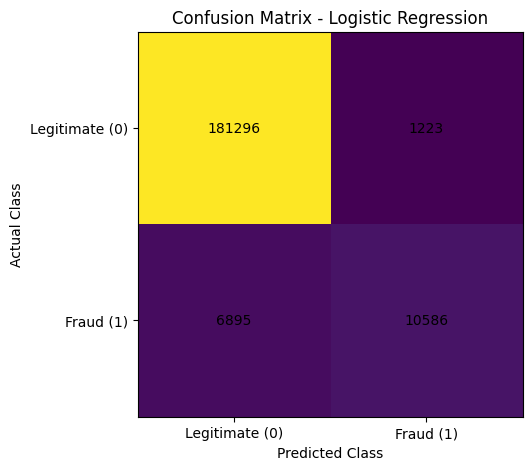

In [ ]:
# Task 10: Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix as a graph
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"])
plt.yticks([0, 1], ["Legitimate (0)", "Fraud (1)"])

# Add values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Conclusion

The experiment successfully demonstrated the implementation of **Logistic Regression for credit card fraud detection**. The complete workflow included data preprocessing, exploratory data analysis, feature scaling, class-imbalance handling, dataset splitting, Sigmoid Function implementation, Binary Cross-Entropy Cost Function, and Gradient Descent optimization.

The trained Logistic Regression model was evaluated using the **Confusion Matrix, Accuracy, Precision, Recall, F1-Score, ROC Curve, and ROC-AUC**. The results demonstrate that accuracy alone is not an adequate performance measure for highly imbalanced fraud detection datasets.

Particular importance was given to **Recall**, because a False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. A suitable fraud detection model should therefore achieve satisfactory Recall while maintaining an acceptable level of False Positives.

Overall, Logistic Regression provides an **interpretable and effective baseline model** for credit card fraud detection. The experiment also demonstrates the importance of selecting appropriate evaluation metrics and handling class imbalance when developing machine learning models for fraud detection.
